In [1]:
import pandas as pd
import requests
from matplotlib import pyplot as plt

In [ ]:


def obter_previsao_open_meteo(lat: float, lon: float) -> pd.DataFrame:
    """Busca a previsão de temperatura e umidade horária na Open-Meteo

    e retorna um DataFrame do Pandas.
    """
    # Endpoint público da Open-Meteo
    url = "https://api.open-meteo.com/v1/forecast"

    # Parâmetros da requisição (exemplo: Goiânia - Lat: -16.68, Lon: -49.25)
    params = {
        "latitude": lat,
        "longitude": lon,
        "hourly": ["temperature_2m", "relative_humidity_2m"],
        "timezone": "auto",
    }

    # Requisição HTTP GET
    response = requests.get(url, params=params)
    response.raise_for_status()  # Levanta erro caso a requisição falhe

    data = response.json()

    # Estruturação dos dados em DataFrame
    df = pd.DataFrame(
        {
            "data_hora": pd.to_datetime(data["hourly"]["time"]),
            "temperatura_c": data["hourly"]["temperature_2m"],
            "umidade_relativa_%": data["hourly"]["relative_humidity_2m"],
        }
    )

In [2]:
url = "https://api.open-meteo.com/v1/forecast"

lat= input("Indique uma latitude: ")
longitude = input("Indique uma longitude: ")

params = {
        "latitude": lat,
        "longitude": longitude,
        "hourly": ["temperature_2m", "relative_humidity_2m"],
        "timezone": "auto",
}

response = requests.get(url, params= params)

print(response.json())

Indique uma latitude: -23.33
Indique uma longitude: -46.38
{'latitude': -23.304043, 'longitude': -46.369354, 'generationtime_ms': 0.04184246063232422, 'utc_offset_seconds': -10800, 'timezone': 'America/Sao_Paulo', 'timezone_abbreviation': 'GMT-3', 'elevation': 1011.0, 'hourly_units': {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%'}, 'hourly': {'time': ['2026-08-21T00:00', '2026-08-21T01:00', '2026-08-21T02:00', '2026-08-21T03:00', '2026-08-21T04:00', '2026-08-21T05:00', '2026-08-21T06:00', '2026-08-21T07:00', '2026-08-21T08:00', '2026-08-21T09:00', '2026-08-21T10:00', '2026-08-21T11:00', '2026-08-21T12:00', '2026-08-21T13:00', '2026-08-21T14:00', '2026-08-21T15:00', '2026-08-21T16:00', '2026-08-21T17:00', '2026-08-21T18:00', '2026-08-21T19:00', '2026-08-21T20:00', '2026-08-21T21:00', '2026-08-21T22:00', '2026-08-21T23:00', '2026-08-22T00:00', '2026-08-22T01:00', '2026-08-22T02:00', '2026-08-22T03:00', '2026-08-22T04:00', '2026-08-22T05:00', '2026-08-22T06:00', '

In [ ]:
data = response.json()

In [ ]:
df = pd.read_json(data)

ValueError: Invalid file path or buffer object type: <class 'dict'>

In [ ]:
meu_df = pd.DataFrame({
    "datetime": pd.to_datetime(data['hourly']['time']),
    "temperatura": data['hourly']['temperature_2m'],
    "humidade": data['hourly']['relative_humidity_2m']})

In [ ]:
meu_df['dia'] = meu_df['datetime'].dt.day

In [ ]:
meu_df['data'] = meu_df['datetime'].dt.date

In [ ]:
df_temperatura = meu_df.groupby('data').agg({
    "temperatura": "mean"
}).reset_index()

In [ ]:
df_temperatura

,data,temperatura
0,2026-08-19,27.412500
1,2026-08-20,28.450000
2,2026-08-21,27.900000
3,2026-08-22,26.941667
4,2026-08-23,28.025000
5,2026-08-24,29.429167
6,2026-08-25,30.200000


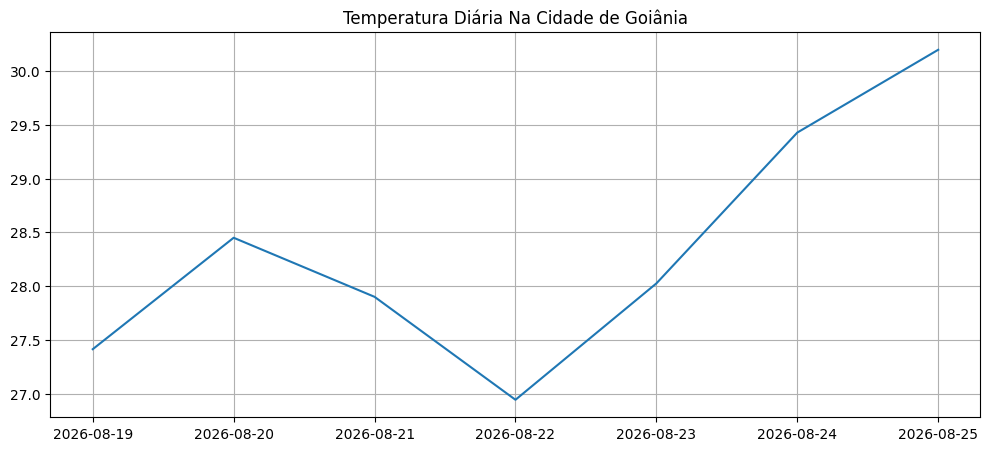

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(df_temperatura["data"], df_temperatura["temperatura"])

plt.title("Temperatura Diária Na Cidade de Goiânia")

plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import requests


def buscar_serie_bcb(
    codigo_serie: int, data_inicio: str = None, data_fim: str = None
) -> pd.DataFrame:
    """Busca uma série temporal no SGS do Banco Central do Brasil.

    :param codigo_serie: Código numérico da série (ex: 432 para Selic, 10813
    para Dólar)
    :param data_inicio: Data inicial no formato 'DD/MM/AAAA' (opcional)
    :param data_fim: Data final no formato 'DD/MM/AAAA' (opcional)
    :return: DataFrame contendo 'data' (datetime) e 'valor' (float)
    """
    url = f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo_serie}/dados"

    # Define parâmetros de data na URL se fornecidos
    params = {"format": "json"}
    if data_inicio:
        params["dataInicial"] = data_inicio
    if data_fim:
        params["dataFinal"] = data_fim

    # Executa a requisição HTTP GET
    response = requests.get(url, params=params)
    response.raise_for_status()

    # Transforma o JSON em DataFrame
    df = pd.DataFrame(response.json())

    # Tratamento de tipos de dados
    df["data"] = pd.to_datetime(df["data"], format="%d/%m/%Y")
    df["valor"] = pd.to_numeric(df["valor"], errors="coerce")

    # Ordena cronologicamente
    df = df.sort_values("data").reset_index(drop=True)

    return df


# Exemplo de uso: Buscar histórico do Dólar e da Taxa Selic
if __name__ == "__main__":
    # Código 10813 = Dólar comercial (venda)
    df_dolar = buscar_serie_bcb(
        codigo_serie=10813, data_inicio="01/01/2023", data_fim="19/08/2026"
    )

    print("--- Cotação do Dólar (Últimas entradas) ---")
    print(df_dolar.tail())

    # Código 432 = Meta da Taxa Selic
    df_selic = buscar_serie_bcb(
        codigo_serie=432, data_inicio="01/01/2023", data_fim="19/08/2026"
    )

    print("\n--- Meta Taxa Selic (% a.a.) ---")
    print(df_selic.tail())

In [ ]:
!pip install python-bcb

In [ ]:
from bcb import sgs

df = sgs.get({"selic": 432, "ipca": 433}, "2022-01-01")

In [ ]:
df = df.reset_index()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1692 entries, 0 to 1691
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1692 non-null   datetime64[ns]
 1   selic   1692 non-null   float64       
 2   ipca    55 non-null     float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 39.8 KB


In [ ]:
df = df.dropna()

In [ ]:
from numpy._core import numeric
df.describe()

,Date,selic,ipca
count,55,55.000000,55.000000
mean,2024-03-31 23:07:38.181818112,12.972727,0.409091
min,2022-01-01 00:00:00,9.250000,-0.680000
25%,2023-02-15 00:00:00,11.500000,0.220000
50%,2024-04-01 00:00:00,13.750000,0.410000
75%,2025-05-16 12:00:00,14.250000,0.585000
max,2026-07-01 00:00:00,15.000000,1.620000
std,NaN,1.677515,0.384603


In [ ]:
from bcb import currency

In [ ]:


# Consulta a cotação PTAX do Euro e Dólar no período especificado
df_ptax = currency().get(
    symbols=["EUR", "USD"], start="2024-01-01", end="2024-01-30"
)

print(df_ptax.head())

TypeError: 'module' object is not callable

In [ ]:
from bcb import IFDATA

In [ ]:

ifdata = IFDATA()

# Lista as datas bases disponíveis para consulta no sistema
print("Datas bases disponíveis:", ifdata.dates[:5])

# Lista os relatórios disponíveis (Ex: Resumo, Ativo, Passivo, DRE)
print("Relatórios:", ifdata.reports)

# Baixa o relatório de resumo do primeiro trimestre disponível
df_bancos = ifdata.get(date=ifdata.dates[0], system="Bancos")
print(df_bancos.head())

NameError: name 'IFDATA' is not defined

In [36]:
import numpy as np

In [37]:
# Obter temperatura


def obter_temperatura_humidade_a(latitude, longitude)-> pd.DataFrame:
      """Uma função que retorna a temperatura e a humidade relativa de
      de uma cidade conforme a latitude e a logitude oferecida"""

      url = "https://api.open-meteo.com/v1/forecast"

      # lat= input("Indique uma latitude: ")
      # longitude = input("Indique uma longitude: ")

      params = {
              "latitude": latitude,
              "longitude": longitude,
              "hourly": ["temperature_2m", "relative_humidity_2m"],
              "timezone": "auto",
      }

      # response = requests.get(url, params= params)

      # print(response.json())

      response = requests.get(url, params= params)

      data = response.json()


      latitude = data['latitude']
      longitude = data['longitude']
      zona_horario = data['timezone']
      datetime = data['hourly']['time']
      temperatura = data['hourly']['temperature_2m']
      humidade_relativa = data['hourly']['relative_humidity_2m']

      df = pd.DataFrame({
          "datetime": np.array(pd.to_datetime(datetime)),
          "temperatura": np.array(temperatura),
          "humidade_relativa": np.array(humidade_relativa)
      })

      return df


# dados_a = obter_temperatura_humidade_a(latitude= -78.27, longitude= -106.50)

In [ ]:
# 'latitude': -23.304043,
#  'longitude': -46.369354,

In [40]:
df_buenos_aires = obter_temperatura_humidade_a(latitude= -34.36, longitude= -58.22)

In [42]:
df_buenos_aires.describe()

,datetime,temperatura,humidade_relativa
count,168,168.000000,168.000000
mean,2026-08-24 11:30:00.000000256,10.357143,72.577381
min,2026-08-21 00:00:00,6.300000,49.000000
25%,2026-08-22 17:45:00,8.500000,65.750000
50%,2026-08-24 11:30:00,10.100000,74.500000
75%,2026-08-26 05:15:00,11.900000,79.000000
max,2026-08-27 23:00:00,14.900000,94.000000
std,NaN,2.074007,10.838221


In [ ]:
# Um dashboard com a temperatura das princípais cidades do estado de goiás.

# Primeiro o problema e o cliente depois a engenharia e a solução.